# 03 · The transformer and the mystery of "object queries"

> **Paper:** §3.2 "Transformer encoder/decoder", Fig. 2, Fig. 7 · **Code:** [`models/transformer.py`](../models/transformer.py)

Notebook `02` left us with a sequence of `(850, 1, 256)` image tokens. Now:

1. The **encoder** lets image tokens talk to each other (global context).
2. The **decoder** takes 100 learned **object queries** and turns them into 100 detections.
3. Two small heads map each query's 256-d output to a class and a box.

The concept everyone stumbles on is the object query. We'll take it apart carefully.

In [1]:
%matplotlib inline
import torch, matplotlib.pyplot as plt
from detr_utils import *   # noqa: F403
from util.misc import nested_tensor_from_tensor_list

device = get_device()
model = load_pretrained_detr(device=device)
im = load_image("cats")
single = nested_tensor_from_tensor_list([default_transform(im)]).to(device)
print("device:", device)

/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


device: mps


## 1. The encoder: 850 tokens, all looking at each other

The encoder is 6 standard transformer layers. Each does **self-attention over the image tokens**, so after the encoder every position "knows" about the whole image.

Shapes are unchanged throughout — `(850, 1, 256)` in, `(850, 1, 256)` out. An encoder *refines* tokens; it never changes how many there are.

In [2]:
print(model.transformer.encoder.layers[0])

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (linear1): Linear(in_features=256, out_features=2048, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (linear2): Linear(in_features=2048, out_features=256, bias=True)
  (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.0, inplace=False)
  (dropout2): Dropout(p=0.0, inplace=False)
)


In [3]:
with torch.no_grad():
    feats, poss = model.backbone(single)
    s, m = feats[-1].decompose()
    src = model.input_proj(s).flatten(2).permute(2, 0, 1)   # shape: (850, 1, 256)
    pos = poss[-1].flatten(2).permute(2, 0, 1)              # shape: (850, 1, 256)
    mask = m.flatten(1)                                     # shape: (1, 850)
    memory = model.transformer.encoder(src, src_key_padding_mask=mask, pos=pos)

print("encoder input  :", tuple(src.shape))
print("encoder output :", tuple(memory.shape), "  <- 'memory', same shape")
print()
print("attention matrix per layer per head:",
      f"({src.shape[0]} x {src.shape[0]}) = {src.shape[0]**2:,} weights")
print("layers:", len(model.transformer.encoder.layers), " heads:", model.transformer.nhead)

encoder input  : (850, 1, 256)
encoder output : (850, 1, 256)   <- 'memory', same shape

attention matrix per layer per head: (850 x 850) = 722,500 weights
layers: 6  heads: 8


Why bother? The paper's ablation (**Table 2**) removes the encoder entirely: AP falls from 40.6 to 36.7, and **−6.0 AP on large objects**. Their explanation (§4.2):

> *"The encoder seems to separate instances already, which likely simplifies object extraction and localization for the decoder."*

A large object spans many grid cells; only global attention can bind them into a single thing. We'll *see* this happening in notebook `05`.

## 2. Object queries: 100 learned vectors, and what they are not

Here is the entire definition, from [`models/detr.py:39`](../models/detr.py#L39):

```python
self.query_embed = nn.Embedding(num_queries, hidden_dim)   # (100, 256)
```

That's it. **100 vectors of 256 numbers, learned by gradient descent, then frozen at inference.** They do not depend on the image in any way.

In [4]:
q = model.query_embed.weight            # shape: (100, 256)
print("query_embed.weight:", tuple(q.shape))
print("depends on the input image?  No -- it is an nn.Parameter, identical for every photo.")
print()
print("first query, first 8 dims:", [round(v, 3) for v in q[0, :8].tolist()])
print("norms: min %.2f  max %.2f  mean %.2f" % (q.norm(dim=1).min(), q.norm(dim=1).max(), q.norm(dim=1).mean()))

query_embed.weight: (100, 256)
depends on the input image?  No -- it is an nn.Parameter, identical for every photo.



first query, first 8 dims: [1.099, 1.035, 0.276, -1.741, -1.164, -0.017, 0.612, -0.133]
norms: min 14.05  max 17.55  mean 15.81


/var/folders/sc/3xlc_nj5631djyp6p32s35z40000gn/T/ipykernel_20028/1840846290.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  print("norms: min %.2f  max %.2f  mean %.2f" % (q.norm(dim=1).min(), q.norm(dim=1).max(), q.norm(dim=1).mean()))


### The clearest way to think about it

A query is a **standing question** the model asks about every image. Loosely: *"is there a smallish object in the lower-left?"* Query 0 asks its question, query 1 asks a different one, and so on 100 times — **in parallel**, all in one forward pass.

Common misconceptions, cleared up:

| Myth | Reality |
|---|---|
| "A query is a region proposal" | No — it carries no coordinates, and is the same for every image |
| "Query *k* always detects class *k*" | No — Fig. 5 shows one model finding 24 giraffes; slots aren't class-bound |
| "Queries are generated from the image" | No — they're `nn.Parameter`s, fixed after training |
| "They're like NLP decoder tokens" | Closer, but NLP decodes **autoregressively**, one token at a time. DETR decodes all 100 **at once** |

### The odd bit: the decoder's input is all zeros

Look at [`models/transformer.py:55`](../models/transformer.py#L55):

In [5]:
import inspect
src_lines = inspect.getsource(type(model.transformer).forward)
print(src_lines)

    def forward(self, src, mask, query_embed, pos_embed):
        # flatten NxCxHxW to HWxNxC
        bs, c, h, w = src.shape
        src = src.flatten(2).permute(2, 0, 1)
        pos_embed = pos_embed.flatten(2).permute(2, 0, 1)
        query_embed = query_embed.unsqueeze(1).repeat(1, bs, 1)
        mask = mask.flatten(1)

        tgt = torch.zeros_like(query_embed)
        memory = self.encoder(src, src_key_padding_mask=mask, pos=pos_embed)
        hs = self.decoder(tgt, memory, memory_key_padding_mask=mask,
                          pos=pos_embed, query_pos=query_embed)
        return hs.transpose(1, 2), memory.permute(1, 2, 0).view(bs, c, h, w)



`tgt = torch.zeros_like(query_embed)` — the decoder's *content* stream starts at **zero**, and `query_embed` is passed separately as `query_pos`, added to the query and key at every attention layer (exactly like the spatial positional encoding in notebook `02`).

So an object query is a **positional encoding for output slots**. The paper calls them *"learnt positional encodings that we refer to as object queries"* (§3.2). All content comes from attending to the image; the query only decides *what to go looking for*.

Why must the 100 be different from each other? Because self-attention is permutation-invariant: *"since the decoder is also permutation-invariant, the N input embeddings must be different to produce different results."* Identical queries would produce 100 identical boxes.

## 3. Running the decoder

Each decoder layer does three things, in order:

1. **Self-attention among the 100 queries** — how they avoid duplicating each other
2. **Cross-attention into encoder memory** — how they actually look at the image
3. **FFN** — per-query processing

In [6]:
print(model.transformer.decoder.layers[0])

TransformerDecoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (linear1): Linear(in_features=256, out_features=2048, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (linear2): Linear(in_features=2048, out_features=256, bias=True)
  (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (dropout1): Dropout(p=0.0, inplace=False)
  (dropout2): Dropout(p=0.0, inplace=False)
  (dropout3): Dropout(p=0.0, inplace=False)
)


In [7]:
with torch.no_grad():
    query_embed = model.query_embed.weight.unsqueeze(1).repeat(1, 1, 1)  # (100, B=1, 256)
    tgt = torch.zeros_like(query_embed)                                   # (100, 1, 256)
    hs = model.transformer.decoder(tgt, memory, memory_key_padding_mask=mask,
                                   pos=pos, query_pos=query_embed)

print("queries in :", tuple(tgt.shape),    " (all zeros)")
print("memory     :", tuple(memory.shape), " (850 image tokens)")
print("decoder out:", tuple(hs.shape),     " <- (n_layers, 100, B, 256)")
print()
print("6 layers are returned because return_intermediate_dec=True:")
print("  the training loss is applied after EVERY layer ('auxiliary decoding losses', §3.2)")

queries in : (100, 1, 256)  (all zeros)
memory     : (850, 1, 256)  (850 image tokens)
decoder out: (6, 100, 1, 256)  <- (n_layers, 100, B, 256)

6 layers are returned because return_intermediate_dec=True:
  the training loss is applied after EVERY layer ('auxiliary decoding losses', §3.2)


Note the shape `(6, 100, 1, 256)`: the decoder hands back its output after **each** of the 6 layers, not just the last. That's for the auxiliary losses. At inference only `hs[-1]` is used — see [`models/detr.py:69`](../models/detr.py#L69), `outputs_class[-1]`.

## 4. Two heads turn 256-d vectors into detections

In [8]:
hs_ = hs.transpose(1, 2)               # (6, B, 100, 256) -- how detr.py sees it
print("hs:", tuple(hs_.shape))

with torch.no_grad():
    outputs_class = model.class_embed(hs_)            # (6, B, 100, 92)
    outputs_coord = model.bbox_embed(hs_).sigmoid()   # (6, B, 100, 4)

print("class_embed -> :", tuple(outputs_class.shape), "  Linear(256 -> 91+1)")
print("bbox_embed  -> :", tuple(outputs_coord.shape), "  MLP(256->256->256->4) then sigmoid")
print()
print("bbox_embed is a 3-layer MLP:")
for i, l in enumerate(model.bbox_embed.layers):
    print(f"   layer {i}: {l}")
print()
print("sigmoid guarantees cx,cy,w,h land in [0,1]:")
print("   min %.4f  max %.4f" % (outputs_coord.min(), outputs_coord.max()))

hs: (6, 1, 100, 256)
class_embed -> : (6, 1, 100, 92)   Linear(256 -> 91+1)
bbox_embed  -> : (6, 1, 100, 4)   MLP(256->256->256->4) then sigmoid

bbox_embed is a 3-layer MLP:
   layer 0: Linear(in_features=256, out_features=256, bias=True)
   layer 1: Linear(in_features=256, out_features=256, bias=True)
   layer 2: Linear(in_features=256, out_features=4, bias=True)

sigmoid guarantees cx,cy,w,h land in [0,1]:
   min 0.0393  max 1.0000


Why an MLP for boxes but a plain `Linear` for classes? Class is a linear readout of a well-separated 256-d space. Box regression needs to *compute* geometry from the embedding — non-linearity helps. Paper: *"The final prediction is computed by a 3-layer perceptron with ReLU... and a linear projection layer"* (§3.2).

### Verify against the real forward pass

In [9]:
with torch.no_grad():
    ref = model(single)
print("hand-rolled vs model():")
print("  logits match:", torch.allclose(outputs_class[-1], ref["pred_logits"], atol=1e-4))
print("  boxes  match:", torch.allclose(outputs_coord[-1], ref["pred_boxes"],  atol=1e-4))

hand-rolled vs model():


  logits match: True


  boxes  match: True


## 5. Predictions sharpen with every decoder layer

Because all 6 layers are supervised, we can decode *each* and watch the model refine its answer. This reproduces the trend in the paper's **Fig. 4** (AP climbs +8.2 from layer 1 to layer 6).

In [10]:
for layer in range(6):
    probs_l = outputs_class[layer, 0].softmax(-1)[:, :-1].cpu()   # (100, 91)
    conf = probs_l.max(-1).values
    n = (conf > 0.9).sum().item()
    labels = sorted({COCO_CLASSES[c] for c in probs_l[conf > 0.9].argmax(-1).tolist()})
    print(f"  decoder layer {layer+1}: {n:2d} confident detections   {labels}")

  decoder layer 1:  4 confident detections   ['cat', 'couch', 'remote']
  decoder layer 2:  5 confident detections   ['cat', 'couch', 'remote']
  decoder layer 3:  5 confident detections   ['cat', 'couch', 'remote']
  decoder layer 4:  5 confident detections   ['cat', 'couch', 'remote']
  decoder layer 5:  5 confident detections   ['cat', 'couch', 'remote']
  decoder layer 6:  5 confident detections   ['cat', 'couch', 'remote']


Layer 1 is typically over-eager (duplicates, spurious boxes); by layer 6 the set has settled. The paper notes that NMS *helps* after layer 1 but *hurts* after layer 6 — by then query self-attention has already removed the duplicates that NMS exists to clean up.

## 6. Do queries specialize? (reproducing Fig. 7)

The paper plots, for each query slot, the centers of every box it predicts across the whole val set. Each slot turns out to own a region and a size regime. Let's do a small version over a handful of images.

In [11]:
names = list(SAMPLE_IMAGES)
all_boxes = []
with torch.no_grad():
    for n in names:
        img = load_image(n)
        o = model(default_transform(img).unsqueeze(0).to(device))
        all_boxes.append(o["pred_boxes"][0].cpu())      # (100, 4)
boxes_stack = torch.stack(all_boxes)                     # (n_images, 100, 4)
print("collected:", tuple(boxes_stack.shape), "= (images, queries, cxcywh)")

collected: (4, 100, 4) = (images, queries, cxcywh)


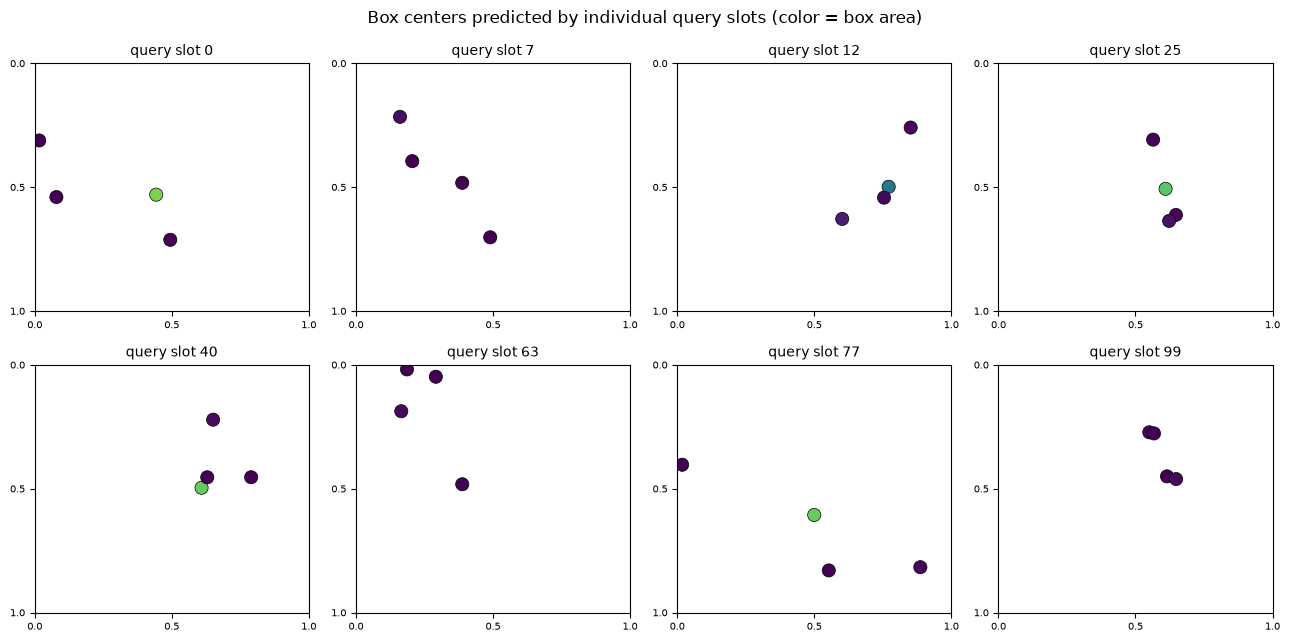

In [12]:
slots = [0, 7, 12, 25, 40, 63, 77, 99]
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, k in zip(axes.ravel(), slots):
    b = boxes_stack[:, k, :]                             # (n_images, 4)
    sizes = (b[:, 2] * b[:, 3]).clamp(0, 1)              # normalized area
    ax.scatter(b[:, 0], b[:, 1], c=sizes, cmap="viridis",
               vmin=0, vmax=1, s=90, edgecolors="k", linewidths=.5)
    ax.set_xlim(0, 1); ax.set_ylim(1, 0)                 # y inverted = image coords
    ax.set_title(f"query slot {k}", fontsize=10)
    ax.set_xticks([0, .5, 1]); ax.set_yticks([0, .5, 1]); ax.tick_params(labelsize=7)
plt.suptitle("Box centers predicted by individual query slots (color = box area)")
plt.tight_layout(); plt.show()

With only 4 images this is a faint echo of Fig. 7, but the point stands: **different slots sit in different places.** Some cluster in a corner; some park at (0.5, 0.5) with a large area — the paper's observation that *"almost all slots have a mode of predicting large image-wide boxes that are common in COCO"*.

To see it properly you'd run this over COCO val (5000 images). Try it if you download the dataset.

## What's next

`04` is the heart of the paper: with 100 predictions and (say) 5 ground-truth objects, **how do you even define a loss?**

### Try it yourself

- Set `slots` to `range(0, 100, 12)` and re-plot. Any slot that looks "unused"?
- In §5, add up how many predictions each layer makes at `threshold=0.5` instead of `0.9`. Does layer 1 produce duplicates?
- Zero out the object queries (`model.query_embed.weight.data.zero_()`) and re-run detection. Why does the output collapse? (Re-read the permutation-invariance note in §2 — then reload the model to undo it!)